In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import (
    StackingClassifier, RandomForestClassifier,
    GradientBoostingClassifier, ExtraTreesClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay,
    matthews_corrcoef, f1_score, roc_auc_score
)
from sklearn.calibration import CalibrationDisplay
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import os
import pickle

In [12]:
df = pd.read_csv('dataset/clean.csv')
X = df.drop(columns=['loan_status'])
y = df['loan_status']


X = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
imbalance_ratio = y_train.value_counts()[0] / y_train.value_counts()[1]

estimators = [
    ('rf', RandomForestClassifier(
        class_weight='balanced', 
        n_estimators=500, 
        max_depth=15, 
        random_state=42, 
        n_jobs=-1
    )),
    
    ('et', ExtraTreesClassifier(
        class_weight='balanced', 
        n_estimators=500, 
        max_depth=15, 
        random_state=42, 
        n_jobs=-1
    )),
    
    ('xgb', XGBClassifier(
        n_estimators=1000, 
        learning_rate=0.1, 
        max_depth=10, 
        scale_pos_weight=imbalance_ratio, 
        subsample=0.8, 
        colsample_bytree=0.8, 
        eval_metric='logloss', 
        random_state=42
    )),
    
    ('lgbm', LGBMClassifier(
        n_estimators=1000, 
        learning_rate=0.1, 
        max_depth=10, 
        class_weight='balanced', 
        subsample=0.8, 
        colsample_bytree=0.8, 
        random_state=42, 
        n_jobs=-1, 
        verbose=-1
    )),
    
    ('svc_rbf', make_pipeline(
        StandardScaler(), 
        SVC(
            class_weight='balanced', 
            probability=True, 
            kernel='rbf', 
            C=1.0, 
            random_state=42
        )
    ))
]



model = StackingClassifier(
    estimators=estimators,
    final_estimator=XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=5, scale_pos_weight=imbalance_ratio, eval_metric='logloss', random_state=42),
    cv=5,
    stack_method='predict_proba',
    passthrough=False,
    n_jobs=-1
)

In [14]:
model.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('rf', ...), ('et', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.","XGBClassifier...ree=None, ...)"
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",5
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'predict_proba'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",-1
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum numb

In [15]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]
print(f"\n=== Stacking ===\n")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
print(f"F1 Score (Macro): {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"Matthews Correlation Coefficient (MCC): {matthews_corrcoef(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred))


=== Stacking ===

Accuracy: 0.9125
ROC AUC Score: 0.9474
F1 Score (Macro): 0.8736
Matthews Correlation Coefficient (MCC): 0.7475

              precision    recall  f1-score   support

           0       0.95      0.94      0.94      4479
           1       0.79      0.82      0.80      1247

    accuracy                           0.91      5726
   macro avg       0.87      0.88      0.87      5726
weighted avg       0.91      0.91      0.91      5726



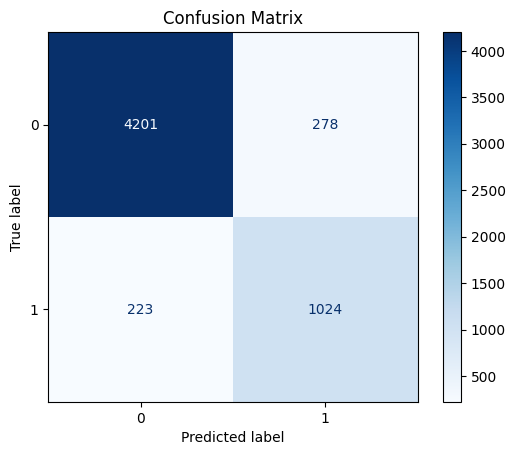

In [16]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()

c:\Users\damar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


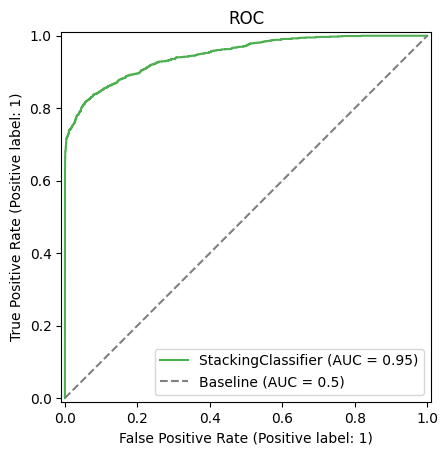

In [17]:
RocCurveDisplay.from_estimator(model, X_test, y_test, color="#4CAF50")
plt.title("ROC")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Baseline (AUC = 0.5)')
plt.legend()
plt.show()

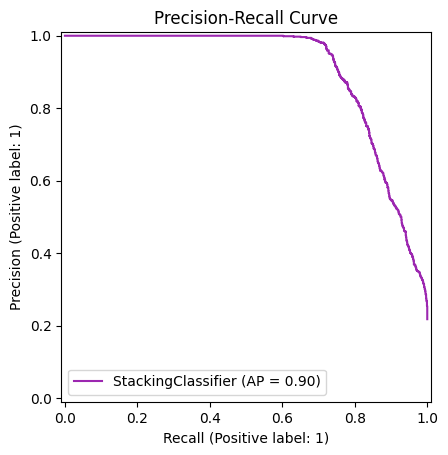

In [18]:
PrecisionRecallDisplay.from_estimator(model, X_test, y_test, color="#9C27B0")
plt.title("Precision-Recall Curve")
plt.show()

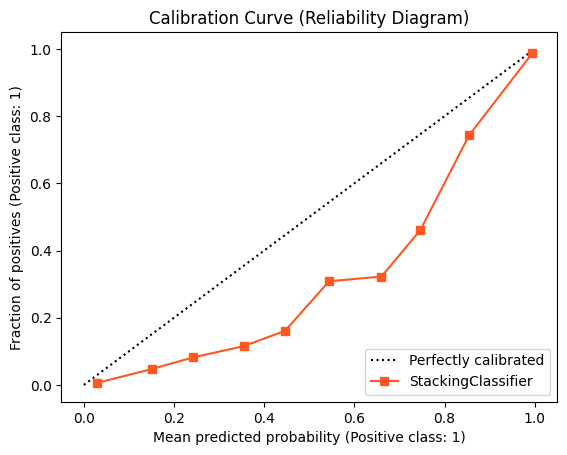

In [19]:
CalibrationDisplay.from_estimator(model, X_test, y_test, n_bins=10, color='#FF5722')
plt.title("Calibration Curve (Reliability Diagram)")
plt.show()

In [20]:
os.makedirs("model_save", exist_ok=True)
model_path = "model_save/stacking.pkl"
with open(model_path, "wb") as f:
    pickle.dump(model, f)
print(f"Model successfully saved to {model_path}")

Model successfully saved to model_save/stacking.pkl
